In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
df = pd.read_csv('../data/processed/cleaned_grades.csv')

df.head()

,Number,Average_GPA,Instructor_Avg_GPA,College_ACES,College_Business,College_Education,College_Engineering,College_FAA,College_LAS,College_Languages,College_Media,College_Other
0,100,3.75,3.75,False,False,False,False,False,False,False,False,True
1,200,3.88,3.89,False,False,False,False,False,False,False,False,True
2,211,3.96,3.89,False,False,False,False,False,False,False,False,True
3,215,3.66,3.57,False,False,False,False,False,False,False,False,True
4,287,3.82,3.82,False,False,False,False,False,False,False,False,True


In [32]:
TARGET_COLUMN = 'Average_GPA'  # <-- CHANGE THIS IF NEEDED

y = df[TARGET_COLUMN]
X = df.drop(columns=[TARGET_COLUMN])

In [33]:
df = df.dropna()

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [37]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{name} Results:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)

evaluate_model('Linear Regression', y_test, lr_pred)
evaluate_model('Random Forest', y_test, rf_pred)


Linear Regression Results:
MAE: 0.17167685023217133
RMSE: 0.23159280155539466
R²: 0.6214507561291065

Random Forest Results:
MAE: 0.15886162459141034
RMSE: 0.21411859144617712
R²: 0.6764204804617102


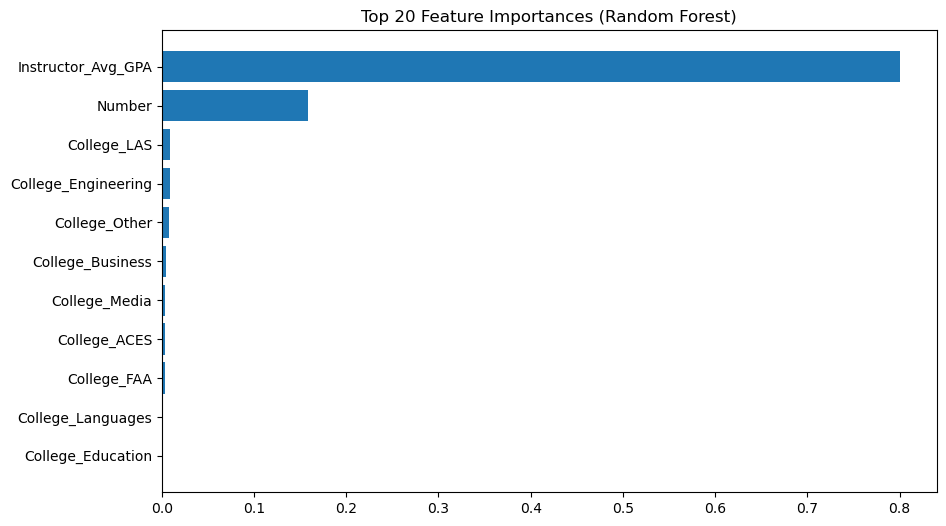

In [38]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

indices = np.argsort(importances)[-20:]  # top 20 features

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Top 20 Feature Importances (Random Forest)')
plt.show()